In [1]:
# !pip install python-Levenshtein

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "raw"
inject_roles = False
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
paths = get_dataset_paths(enhancement)

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)

In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

Train Loss (Epoch 1): 0.6212
Dev Eval (Epoch 1):
  precision: 0.6395
  recall: 0.6100
  f1: 0.5981
  bleu: 0.4815
  edit_distance_avg: 57.2263
  predicate_accuracy: 0.7060
  valid_logical_form_ratio: 0.9867
Train Loss (Epoch 2): 0.1712
Dev Eval (Epoch 2):
  precision: 0.8550
  recall: 0.8220
  f1: 0.8320
  bleu: 0.7148
  edit_distance_avg: 26.8580
  predicate_accuracy: 0.8890
  valid_logical_form_ratio: 0.9990
Train Loss (Epoch 3): 0.1097
Dev Eval (Epoch 3):
  precision: 0.9329
  recall: 0.9208
  f1: 0.9245
  bleu: 0.8503
  edit_distance_avg: 14.6177
  predicate_accuracy: 0.9376
  valid_logical_form_ratio: 0.9997
Train Loss (Epoch 4): 0.0771
Dev Eval (Epoch 4):
  precision: 0.9692
  recall: 0.9643
  f1: 0.9657
  bleu: 0.8993
  edit_distance_avg: 7.5497
  predicate_accuracy: 0.9655
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 5): 0.0577
Dev Eval (Epoch 5):
  precision: 0.9852
  recall: 0.9827
  f1: 0.9835
  bleu: 0.9249
  edit_distance_avg: 3.6083
  predicate_accuracy: 0.9804
  

Predictions saved to: /notebooks/meta-semantic-research/predictions/raw/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/raw/t5-small_test_metrics.csv
Test Eval:
  precision: 0.9850
  recall: 0.9766
  f1: 0.9800
  bleu: 0.4918
  edit_distance_avg: 9.9127
  predicate_accuracy: 0.9755
  valid_logical_form_ratio: 0.9997


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.9850,0.9766,0.9800,0.4918,9.9127,0.9755,0.9997


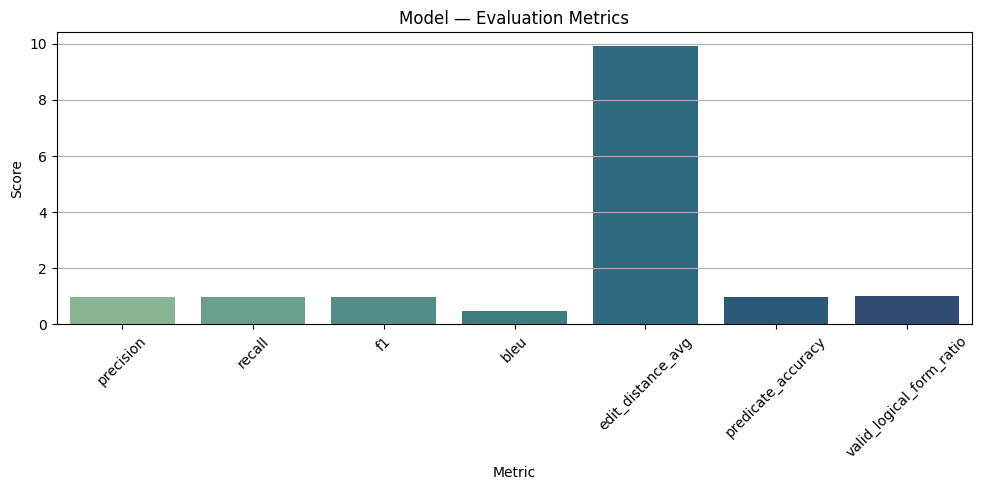

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/raw/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/raw/t5-small_gen_metrics.csv
Gen Eval:
  precision: 0.9686
  recall: 0.8905
  f1: 0.9171
  bleu: 0.4085
  edit_distance_avg: 60.6684
  predicate_accuracy: 0.9201
  valid_logical_form_ratio: 0.9995


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.9686,0.8905,0.9171,0.4085,60.6684,0.9201,0.9995


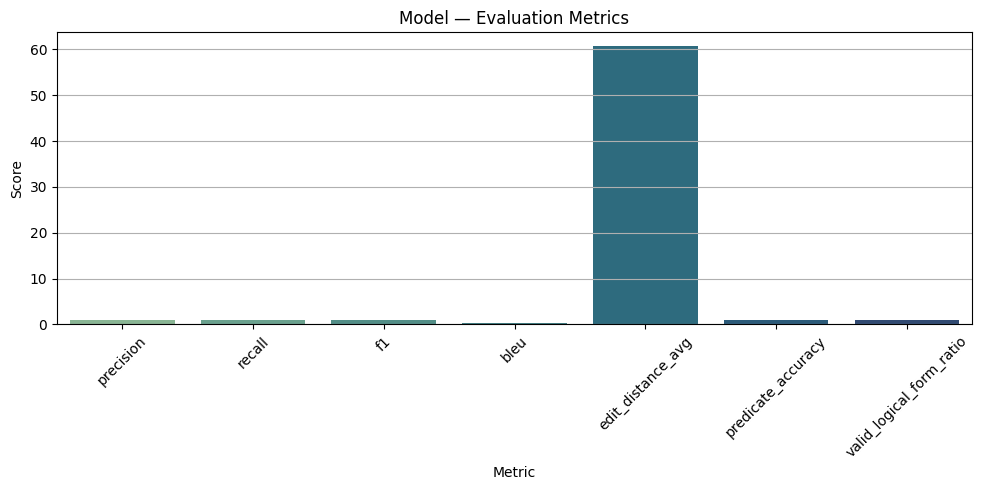

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

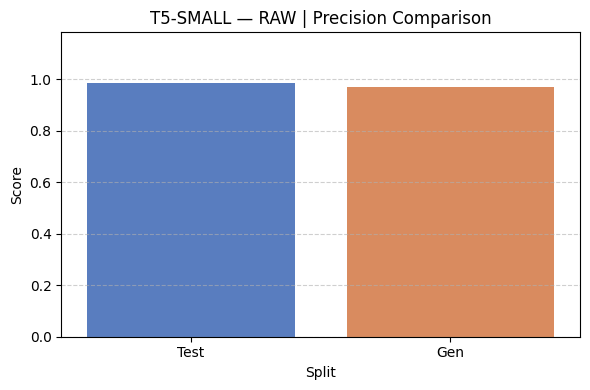

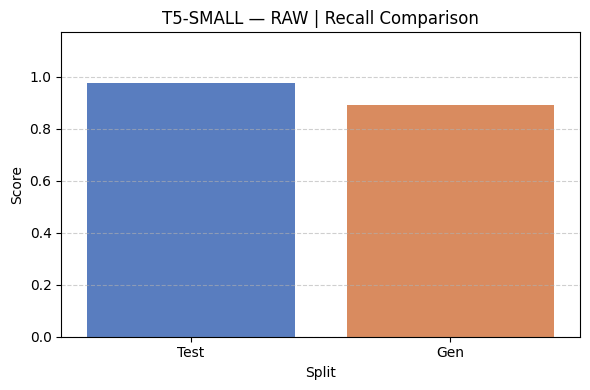

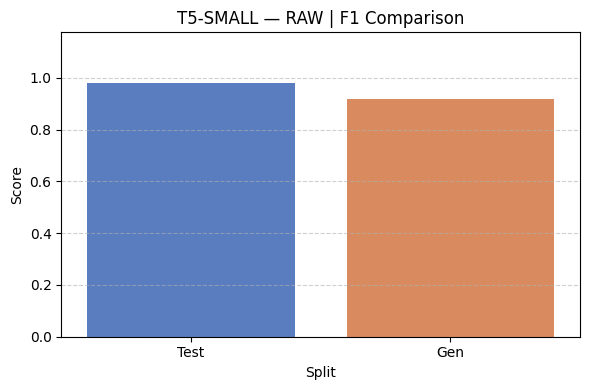

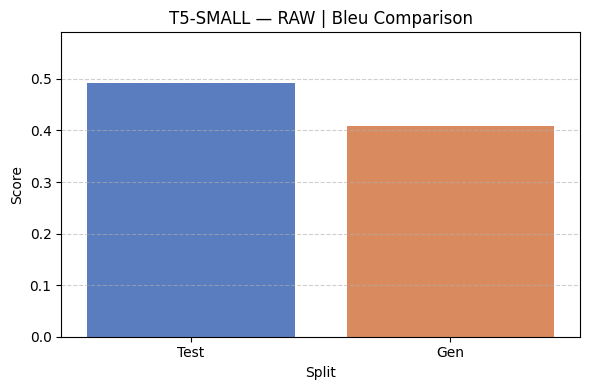

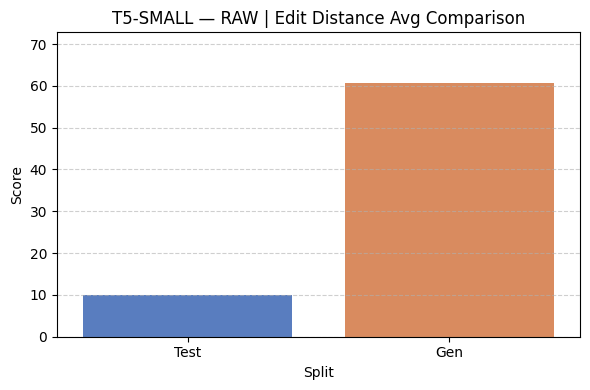

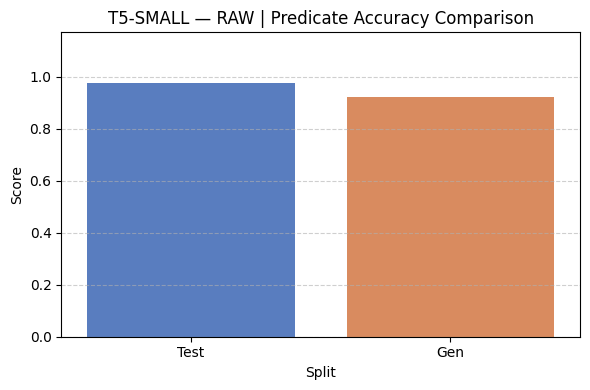

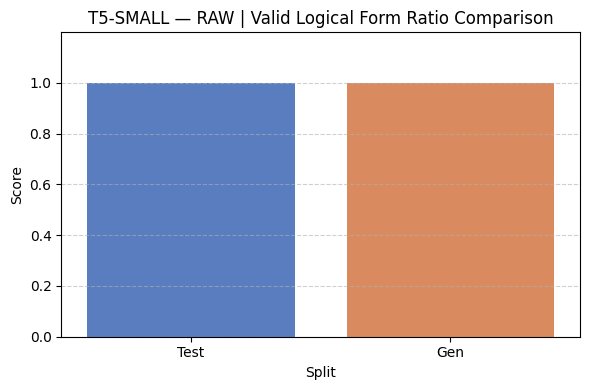

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)